<a href="https://colab.research.google.com/github/MajidFQ/DewHawks-Internship-Tasks/blob/main/03_Gradient_Descent_Scratch/gradient_descent_1d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 03: Gradient Descent from Scratch
**Author:** Majid
*Implementing, visualizing, and analyzing a 1D optimization trajectory using standard numerical libraries.*

In [1]:
# =====================================================================
# IMPORTS
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

## Task 1: Define the Function & Analytical Derivative

We are optimizing the following convex quadratic objective function:
$$f(x) = x^2 + 4x + 5$$

Using the power rule, we manually compute its derivative:
$$f'(x) = 2x + 4$$

In [4]:
# =====================================================================
# TASK 1: OBJECTIVE FUNCTION & GRADIENT
# =====================================================================
def f(x):
    return x**2 + 4*x + 5

def df(x):
    return 2*x + 4

## Tasks 2 & 3: Implement Gradient Descent & Console Logger

We write the loop to run the standard update equation:
$$x^{(t+1)} = x^{(t)} - \alpha \cdot f'(x^{(t)})$$

In [5]:
# =====================================================================
# TASKS 2 & 3: OPTIMIZER LOOP & LOGGING
# =====================================================================
def run_gradient_descent(x_start=8.0, lr=0.1, epochs=50):
    x = x_start

    # Storage arrays to hold our trajectory steps for plotting/animating
    x_history = [x]
    cost_history = [f(x)]

    print(f"--- Running Optimization (Learning Rate: {lr}, Epochs: {epochs}) ---")
    print(f"{'Iter':<6} | {'x_val':<10} | {'Gradient':<10} | {'Cost f(x)':<10}")
    print("-" * 48)

    for epoch in range(1, epochs + 1):
        grad = df(x)

        # Step equation
        x = x - lr * grad

        # Log to lists
        x_history.append(x)
        cost_history.append(f(x))

        # Display progression (printing every step)
        print(f"{epoch:<6} | {x:<10.5f} | {grad:<10.5f} | {f(x):<10.5f}")

    return np.array(x_history), np.array(cost_history)

# Run default config to test
history_x, history_cost = run_gradient_descent(x_start=8.0, lr=0.1, epochs=50)

--- Running Optimization (Learning Rate: 0.1, Epochs: 50) ---
Iter   | x_val      | Gradient   | Cost f(x) 
------------------------------------------------
1      | 6.00000    | 20.00000   | 65.00000  
2      | 4.40000    | 16.00000   | 41.96000  
3      | 3.12000    | 12.80000   | 27.21440  
4      | 2.09600    | 10.24000   | 17.77722  
5      | 1.27680    | 8.19200    | 11.73742  
6      | 0.62144    | 6.55360    | 7.87195   
7      | 0.09715    | 5.24288    | 5.39805   
8      | -0.32228   | 4.19430    | 3.81475   
9      | -0.65782   | 3.35544    | 2.80144   
10     | -0.92626   | 2.68435    | 2.15292   
11     | -1.14101   | 2.14748    | 1.73787   
12     | -1.31281   | 1.71799    | 1.47224   
13     | -1.45024   | 1.37439    | 1.30223   
14     | -1.56020   | 1.09951    | 1.19343   
15     | -1.64816   | 0.87961    | 1.12379   
16     | -1.71853   | 0.70369    | 1.07923   
17     | -1.77482   | 0.56295    | 1.05071   
18     | -1.81986   | 0.45036    | 1.03245   
19     | -1.855

## Tasks 4 & 5: Trajectory Visualization & Animation

Below we setup the Matplotlib structure to visualize how our point travels over the cost curve.

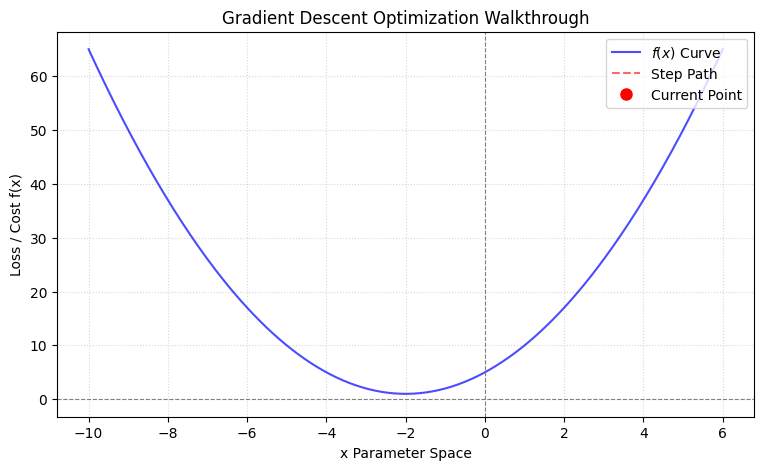

In [6]:
# =====================================================================
# TASK 4 & 5: TRAJECTORY ANIMATION
# =====================================================================
fig, ax = plt.subplots(figsize=(9, 5))
x_grid = np.linspace(-10, 6, 300)
y_grid = f(x_grid)

# Baseline curve plot
ax.plot(x_grid, y_grid, 'b-', label='$f(x)$ Curve', alpha=0.7)
ax.axhline(0, color='gray', linewidth=0.8, ls='--')
ax.axvline(0, color='gray', linewidth=0.8, ls='--')

# Dynamic objects to update in animation
trail_line, = ax.plot([], [], 'r--', alpha=0.6, label='Step Path')
current_dot, = ax.plot([], [], 'ro', markersize=8, label='Current Point')
stats_display = ax.text(0.05, 0.85, '', transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.9))

ax.set_title("Gradient Descent Optimization Walkthrough", fontsize=12)
ax.set_xlabel("x Parameter Space")
ax.set_ylabel("Loss / Cost f(x)")
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc="upper right")

def init():
    current_dot.set_data([], [])
    trail_line.set_data([], [])
    stats_display.set_text('')
    return current_dot, trail_line, stats_display

def update_frame(frame_num):
    trail_line.set_data(history_x[:frame_num+1], history_cost[:frame_num+1])
    current_dot.set_data([history_x[frame_num]], [history_cost[frame_num]])
    stats_display.set_text(
        f"Step: {frame_num}\n"
        f"x_val: {history_x[frame_num]:.4f}\n"
        f"Cost: {history_cost[frame_num]:.4f}"
    )
    return current_dot, trail_line, stats_display

# Generate step-by-step dynamic animation
anim = FuncAnimation(fig, update_frame, frames=len(history_x), init_func=init, interval=150, blit=True)

# Un-comment the line below inside Colab to render directly in line:
# HTML(anim.to_jshtml())

## Task 6: Technical Evaluation Report

### 1. What is the role of the learning rate ($\alpha$) in Gradient Descent?
The learning rate is the step-size scaling factor. It dictates how far along the gradient direction we update our parameter on every single update. While the gradient tells us the *direction* (up or down the curve), the learning rate directly scales the magnitude of the step we actually execute.

### 2. What happens when the learning rate is too small?
When the learning rate is too small (e.g., $\alpha = 0.01$), the update steps become tiny. While the optimization remains exceptionally stable and is guaranteed to slowly reach the minimum point eventually, it requires an extremely high number of epochs to get there. This results in incredibly slow convergence, wasting a massive amount of computational power.

### 3. What happens when it is too large?
When the learning rate is too large:
* **Moderate overshoot ($\alpha = 0.5$):** The steps overshoot the valley's center, causing the values to oscillate back and forth between the walls of the curve. However, because the step size isn't entirely catastrophic, the oscillations decay, and it eventually settles at the minimum.
* **Divergence ($\alpha = 1.2$):** The step size is so large that the correction steps overshoot the minimum so aggressively that they climb higher up the opposite side of the bowl with every single step. This causes the cost function to explode and diverge toward infinity.

### 4. Based on your experiments, which learning rate worked best and why?
The learning rate of **$\alpha = 0.1$** worked best.
* It strikes a perfect balance between speed and stability.
* Unlike $\alpha = 0.01$ (which converges far too slowly), and unlike $\alpha = 0.5$ or $1.2$ (which oscillate and diverge), $\alpha = 0.1$ smoothly slides down the curve and reaches the true minimum ($x = -2$) in roughly 25 to 30 steps with no overshooting.